In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Libraries

In [99]:
import os
import json
import tensorflow as tf
import pathlib
import pandas as pd
import datetime
# text layers
from tensorflow.keras.layers import TextVectorization, ZeroPadding2D, Conv2D, MaxPool2D, Flatten, Dense, Dropout, Concatenate
from tensorflow.keras.layers import Embedding, Bidirectional

from tensorflow.keras.regularizers import L2

# learning rate optimization
from tensorflow.keras.optimizers import Adam

# Dataset
# from tensorflow.data.Dataset import from_tensor_slices

import numpy as np

from tensorflow.keras import Sequential

# embeddings using transformers
from sentence_transformers import SentenceTransformer


import shutil
import matplotlib as mpl

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import ZeroPadding2D, Conv2D, MaxPool2D, Flatten, Dense, Dropout, Concatenate, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.regularizers import L2


# performence measurement
from tensorflow.keras.metrics import BinaryAccuracy, FalseNegatives, FalsePositives, F1Score, BinaryCrossentropy, MeanSquaredError, TruePositives, TrueNegatives, Precision, Recall, AUC #, RootMeanSquaredError

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



# model stoping criteria
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [100]:
mpl.rcParams['figure.figsize'] = (12, 10)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [29]:
BATCH_SIZE = 32


# Data preparation

## Load the exact path of json file and image folder path. Remove extra path at the end (check image_path value form the json file)

In [5]:
test_json_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_test_gold/CT23_1A_checkworthy_multimodal_english_test_gold.jsonl"

test_image_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_test/"


train_json_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/CT23_1A_checkworthy_multimodal_english_train.jsonl"
train_image_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/"

dev_json_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/CT23_1A_checkworthy_multimodal_english_dev.jsonl"
dev_image_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/"

dev_test_json_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/CT23_1A_checkworthy_multimodal_english_dev_test.jsonl"

dev_test_image_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/"

## Load the json files

In [6]:
def load_json(path):
  list_data = []
  with open(path, 'r') as file:
    for line in file:
      data = json.loads(line)
      list_data.append(data)
  return list_data

In [7]:
test_data = load_json(test_json_path)
train_data = load_json(train_json_path)
dev_data = load_json(dev_json_path)
dev_test_data = load_json(dev_test_json_path)

print(f"Length of test data {len(test_data)}")
print(f"Length of train data {len(train_data)}")
print(f"Length of dev data {len(dev_data)}")
print(f"Length of dev_test data {len(dev_test_data)}")

Length of test data 736
Length of train data 2356
Length of dev data 271
Length of dev_test data 548


In [8]:
test_data[0]

{'tweet_id': '1196687191747039232',
 'tweet_url': 'https://twitter.com/user/status/1196687191747039232',
 'tweet_text': 'Got my first paying job(digital marketing) 💃🏽 please follow me on IG guys 🙏👏🏽. https://t.co/v6N1kJ24Sb',
 'ocr_text': '',
 'image_path': 'images_labeled/test/1196687191747039232.jpg',
 'image_url': 'http://pbs.twimg.com/ext_tw_video_thumb/1196687124055109635/pu/img/oYYUUZUaKOAGVOWZ.jpg',
 'class_label': 'No'}

## concat the imag ecaption and ocr text , labels. Then put into  different lists

In [9]:
train_text = [d['tweet_text'] + ' ' + d['ocr_text'] for d in train_data]
train_labels = [d['class_label'] for d in train_data]
train_labels = [1 if item == "Yes" else 0 for item in train_labels]

dev_text = [d['tweet_text'] + ' ' + d['ocr_text'] for d in dev_data]
dev_labels = [d['class_label'] for d in dev_data]
dev_labels = [1 if item == "Yes" else 0 for item in dev_labels]

dev_test_text = [d['tweet_text'] + ' ' + d['ocr_text'] for d in dev_test_data]
dev_test_labels = [d['class_label'] for d in dev_test_data]
dev_test_labels = [1 if item == "Yes" else 0 for item in dev_test_labels]

test_text = [d['tweet_text'] + ' ' + d['ocr_text'] for d in test_data]
test_labels = [d['class_label'] for d in test_data]
test_labels = [1 if item == "Yes" else 0 for item in test_labels]

## Add image paths in a list

In [10]:
train_full_image_paths = [os.path.join(train_image_path, d['image_path']) for d in train_data]

dev_full_image_paths = [os.path.join(dev_image_path, d['image_path']) for d in dev_data]


dev_test_full_image_paths = [os.path.join(dev_test_image_path, d['image_path']) for d in dev_test_data]

test_full_image_paths = [os.path.join(test_image_path, d['image_path']) for d in test_data]




In [ ]:
print(max(map(len, train_text)))
print(max(map(len, dev_text)))
print(max(map(len, dev_test_text)))
print(max(map(len, test_text)))

7626
4601
3490
8504


In [ ]:
word_count = 0
for i in dev_test_text:
  if len(i.split()) > word_count:
    word_count = len(i.split())
print(word_count)

# train text - 1157
# test text - 1391
# dev text - 806

# dev test text - 561

561


In [ ]:
len(train_text[0])

592

# Image Resizing and rescaling

In [11]:
IMG_SIZE = 224

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Checking different layers from tf

In [ ]:
MAX_VOCAB_LENGTH = 20000
MAX_LENGTH = 1000
text_vectorizer = TextVectorization(max_tokens = MAX_VOCAB_LENGTH,
                                   standardize="lower_and_strip_punctuation",
                                   split="whitespace",
                                   ngrams=None ,
                                   output_mode="int",
                                   output_sequence_length=MAX_LENGTH
                                   )

In [ ]:
MAX_VOCAB_LENGTH = 20000
MAX_LENGTH = 25
OUTPUT_DIM = 128
embedding = Embedding(input_dim = MAX_VOCAB_LENGTH,
                       output_dim = OUTPUT_DIM,
                       input_length = MAX_LENGTH)

In [ ]:
text_vectorizer.adapt(train_text)

In [ ]:
embedding_vec = embedding(text_vectorizer(["hello world"]))

In [ ]:
embedding_vec.shape

TensorShape([1, 1000, 128])

# Paired tf dataset
 - create dataset from list using from_tensor_slice()

In [ ]:
# # not tokenized
# train_image_path_ds = tf.data.Dataset.from_tensor_slices(train_full_image_paths)
# #text_train_ds        = tf.data.Dataset.from_tensor_slices(train_text)
# train_label_ds       = tf.data.Dataset.from_tensor_slices(train_labels)


# dev_image_path_ds = tf.data.Dataset.from_tensor_slices(dev_full_image_paths)
# #text_dev_ds        = tf.data.Dataset.from_tensor_slices(dev_text)
# dev_label_ds       = tf.data.Dataset.from_tensor_slices(dev_labels)


# test_image_path_ds = tf.data.Dataset.from_tensor_slices(test_full_image_paths)
# #text_test_ds        = tf.data.Dataset.from_tensor_slices(test_text)
# test_label_ds       = tf.data.Dataset.from_tensor_slices(test_labels)

# dev_test_image_path_ds = tf.data.Dataset.from_tensor_slices(dev_test_full_image_paths)
# # text_dev_test_ds        = tf.data.Dataset.from_tensor_slices(dev_test_text)
# dev_test_label_ds       = tf.data.Dataset.from_tensor_slices(dev_test_labels)


## model for creating text embedding vector (not using right now)

In [ ]:
VOCAB_SIZE = 20000
MAX_LENGTH = 128
encoder = TextVectorization(
    max_tokens = VOCAB_SIZE,
    ngrams=None ,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)

In [ ]:
encoder.adapt(train_text)

In [ ]:
model_text_embedding = tf.keras.Sequential([
    encoder,
    Embedding(input_dim = len(encoder.get_vocabulary()),
              output_dim = 64,
              mask_zero = True),
    Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    Bidirectional(tf.keras.layers.LSTM(32)),
    Dense(64, activation = 'relu')

])
model_text_embedding.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# train_text[0]

In [12]:
# predict = model_text_embedding.predict(tf.constant([train_text[0]]))
# predict

## create text embeddings and store in the data set instead of row text with image and labels

In [ ]:
def create_text_embedding_list(model, text_data_list):
  text_embedding_list = []
  for text in text_data_list:
    text_embedding_list.append(model.predict(tf.constant([text])))
  return text_embedding_list

In [ ]:
# dev_text_embedding = create_text_embedding_list(model_text_embedding, dev_text)
# dev_test_text_embedding = create_text_embedding_list(model_text_embedding, dev_test_text)
# test_text_embedding = create_text_embedding_list(model_text_embedding, test_text)

In [ ]:
train_text_embedding = create_text_embedding_list(model_text_embedding, train_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━

## Sentence Transformers for text embedding

In [3]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
train_text_embedding = model.encode(train_text)

In [18]:
train_text_embedding[0].shape

(384,)

In [21]:
test_text_embedding = model.encode(test_text)

In [20]:
dev_test_text_embedding = model.encode(dev_test_text)


In [19]:
dev_text_embedding = model.encode(dev_text)

## Tensore slice for preparing the data

In [32]:
# # not tokenized
train_image_path_ds = tf.data.Dataset.from_tensor_slices(train_full_image_paths)
train_label_ds       = tf.data.Dataset.from_tensor_slices(train_labels)
train_text_embedding_ds = tf.data.Dataset.from_tensor_slices(train_text_embedding)

dev_image_path_ds = tf.data.Dataset.from_tensor_slices(dev_full_image_paths)
dev_text_embedding_ds = tf.data.Dataset.from_tensor_slices(dev_text_embedding)
dev_label_ds       = tf.data.Dataset.from_tensor_slices(dev_labels)


test_image_path_ds = tf.data.Dataset.from_tensor_slices(test_full_image_paths)
test_text_embedding_ds = tf.data.Dataset.from_tensor_slices(test_text_embedding)
test_label_ds       = tf.data.Dataset.from_tensor_slices(test_labels)

dev_test_image_path_ds = tf.data.Dataset.from_tensor_slices(dev_test_full_image_paths)
dev_test_text_embedding_ds = tf.data.Dataset.from_tensor_slices(dev_test_text_embedding)
dev_test_label_ds       = tf.data.Dataset.from_tensor_slices(dev_test_labels)


## pare the text embedding , image, label

In [25]:
paired_train_ds = tf.data.Dataset.zip((train_image_path_ds, train_text_embedding_ds, train_label_ds))
print(paired_train_ds)

paired_test_ds = tf.data.Dataset.zip((test_image_path_ds, test_text_embedding_ds, test_label_ds))
print(paired_test_ds)

paired_dev_ds = tf.data.Dataset.zip((dev_image_path_ds, dev_text_embedding_ds, dev_label_ds))
print(paired_dev_ds)

paired_dev_test_ds = tf.data.Dataset.zip((dev_test_image_path_ds, dev_test_text_embedding_ds, dev_test_label_ds))
print(paired_dev_test_ds)

<_ZipDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(384,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>
<_ZipDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(384,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>
<_ZipDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(384,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>
<_ZipDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(384,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>


## load the image from the image paths and craete final data set  for the model input

In [91]:
def load_prepocess(image_path, text, label):
  image = load_image(image_path)
  return (image, text), tf.expand_dims(label, axis = -1)

In [92]:
train_ds = paired_train_ds.map(load_prepocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = paired_test_ds.map(load_prepocess, num_parallel_calls=tf.data.AUTOTUNE)
dev_ds = paired_dev_ds.map(load_prepocess, num_parallel_calls=tf.data.AUTOTUNE)
dev_test_ds = paired_dev_test_ds.map(load_prepocess, num_parallel_calls=tf.data.AUTOTUNE)

In [93]:
print(train_ds)
print(test_ds)
print(dev_ds)
print(dev_test_ds)

<_ParallelMapDataset element_spec=((TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(384,), dtype=tf.float32, name=None)), TensorSpec(shape=(1,), dtype=tf.int32, name=None))>
<_ParallelMapDataset element_spec=((TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(384,), dtype=tf.float32, name=None)), TensorSpec(shape=(1,), dtype=tf.int32, name=None))>
<_ParallelMapDataset element_spec=((TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(384,), dtype=tf.float32, name=None)), TensorSpec(shape=(1,), dtype=tf.int32, name=None))>
<_ParallelMapDataset element_spec=((TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(384,), dtype=tf.float32, name=None)), TensorSpec(shape=(1,), dtype=tf.int32, name=None))>


In [30]:
# for x, y in train_ds:
#   print(x[0])
#   print('-------')
#   print(y)
#   break

In [94]:
train_ds = train_ds.shuffle(buffer_size = 8, reshuffle_each_iteration = True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(train_ds)

test_ds = test_ds.shuffle(buffer_size = 8, reshuffle_each_iteration = True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(test_ds)

dev_ds = dev_ds.shuffle(buffer_size = 8, reshuffle_each_iteration = True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(dev_ds)


dev_test_ds = dev_test_ds.shuffle(buffer_size = 8, reshuffle_each_iteration = True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(dev_test_ds)



<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 384), dtype=tf.float32, name=None)), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 384), dtype=tf.float32, name=None)), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 384), dtype=tf.float32, name=None)), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 384), dtype=tf.float32, name=None)), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>


# Model Initialization

## early stopping

In [75]:
# early stopping , if no improvement
def early_stoping():
  return EarlyStopping(
      monitor = 'f1_score',
      mode = "auto", # min max auto
      verbose = 1,
      baseline = 0.50, # f1_score base line
      start_from_epoch = 10,
      patience = 5
  )

## save best model

In [76]:
# best model
def checkpoints_model_callbacks(file_path):
  return ModelCheckpoint(
      filepath = file_path,
      monitor = "val_f1_score",
      mode = "max",
      save_best_only = True,
      save_weights_only = False,
      verbose = 1,
  )

## save best weights

In [77]:
# best weights
def checkpoint_model_weights_callbacks(file_path):
    return ModelCheckpoint(
      filepath = file_path,
      monitor = "val_f1_score",
      mode = "max",
      save_weights_only = True,
      save_best_only = False,
      verbose = 1,
  )

In [34]:
IM_SIZE = 224

In [85]:
# import tensorflow as tf
# from tensorflow.keras.layers import ZeroPadding2D, Conv2D, MaxPool2D, Flatten, Dense, Dropout, Concatenate, Input
# from tensorflow.keras.models import Model, Sequential
# from tensorflow.keras.regularizers import L2

def get_base_model(IM_SIZE):
  image_input = Input(shape=(IM_SIZE, IM_SIZE, 3), name='image_input')

  x = ZeroPadding2D(padding=1, data_format='channels_last')(image_input)
  x = Conv2D(64, kernel_size=(3, 3), activation='relu', data_format='channels_last', name = 'conv_1')(x)
  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(64, kernel_size=(3, 3), activation='relu', data_format='channels_last', name = 'conv_2')(x)
  x = MaxPool2D(pool_size=(2, 2), strides=(2, 2), data_format='channels_last')(x)

  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(128, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv2_1')(x)
  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(128, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv2_2')(x)
  x = MaxPool2D(pool_size=(2, 2), strides=(2, 2), data_format='channels_last')(x)

  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(256, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv3_1')(x)
  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(256, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv3_2')(x)
  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(256, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv3_3')(x)
  x = MaxPool2D(pool_size=(2, 2), strides=(2, 2), data_format='channels_last')(x)

  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(512, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv4_1')(x)
  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(512, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv4_2')(x)
  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(512, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv4_3')(x)
  x = MaxPool2D(pool_size=(2, 2), strides=(2, 2), data_format='channels_last')(x)

  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(512, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv5_1')(x)
  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(512, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv5_2')(x)
  x = ZeroPadding2D(padding=1, data_format='channels_last')(x)
  x = Conv2D(512, kernel_size=(3, 3), activation='relu', data_format='channels_last', name='conv5_3')(x)
  conv_output = MaxPool2D(pool_size=(2, 2), strides=(2, 2), data_format='channels_last')(x)

  base_model = Model(inputs=image_input, outputs=conv_output, name='convolutional_base')

  for layer in base_model.layers:
      layer.trainable = False # Keep conv layers frozen

  return base_model

# def load_weights_in_base_model(model):
    # """
    # The function takes the VGG convolutian part and loads
    # the weights from the pre-trained model and then returns the model
    # """
    # This part requires h5py and a defined WEIGHTS_PATH.
    # It's currently not used in the user's workflow, so leaving as is.
    # For a real implementation, you would need to ensure h5py is imported and WEIGHTS_PATH is defined.
    # f = h5py.File(weight_file)
    # for k in range(f.attrs['nb_layers']):
    #     if k >= len(model.layers):
    #         break
    #     g = f['layer_{}'.format(k)]
    #     weights = [g['param_{}'.format(p)] for p in range(g.attrs['nb_params'])]
    #     model.layers[k].set_weights(weights)
    # f.close()
    # return model

In [86]:
def make_final_model(base_image_model, vec_size, do=0.5, l2_strength=1e-5):
    """
    base_image_model : The Keras Model representing the convolutional base (output of get_base_model).
    vec_size : The size of the vectorized text vector.
    n_classes : Number of classes for classification.
    do : Dropout probability.
    l2_strength : The L2 regularization strength.

    output : The full multimodal model that takes image and text vector as inputs.
    """

    # Image branch
    image_input = base_image_model.input
    image_features = base_image_model.output
    image_features = Flatten(name='top_flatter')(image_features)
    image_features = Dense(256, activation='relu', kernel_regularizer=L2(l2_strength), name='image_dense_1')(image_features)
    image_features = Dropout(do)(image_features)
    image_features = Dense(256, activation='sigmoid', kernel_regularizer=L2(l2_strength), name='image_dense_2')(image_features)

    # Text branch
    text_input = tf.keras.Input(shape=(vec_size,), name='text_input')
    text_features = Dense(vec_size, activation='relu', name='aux_input_dense')(text_input) # Process text input through a dense layer

    # Merge image and text features
    merged = Concatenate(axis=-1)([image_features, text_features]) # Concatenate along the feature dimension

    # Final classifier layers
    x = Dropout(do)(merged)
    output = Dense(1, activation='sigmoid', name='output_layer')(x)

    # Create the final multimodal model
    final_model = Model(inputs=[image_input, text_input], outputs=output)

    return final_model

In [87]:
base_model = get_base_model(IM_SIZE)
vgg_16_model = make_final_model(base_model, 384)

In [63]:
# base_model.summary()

In [88]:
vgg_16_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_42   │ (None, 226, 226,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 224, 224,  │      1,792 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_43   │ (None, 226, 226,  │          0 │ conv_1[0][0]      │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, 224, 224,  │     36,928 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 112, 112,  │          0 │ conv_2[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_44   │ (None, 114, 114,  │          0 │ max_pooling2d_15… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1 (Conv2D)    │ (None, 112, 112,  │     73,856 │ zero_padding2d_4… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_45   │ (None, 114, 114,  │          0 │ conv2_1[0][0]     │
│ (ZeroPadding2D)     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2 (Conv2D)    │ (None, 112, 112,  │    147,584 │ zero_padding2d_4… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 56, 56,    │          0 │ conv2_2[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_46   │ (None, 58, 58,    │          0 │ max_pooling2d_16… │
│ (ZeroPadding2D)     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_1 (Conv2D)    │ (None, 56, 56,    │    295,168 │ zero_padding2d_4… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_47   │ (None, 58, 58,    │          0 │ conv3_1[0][0]     │
│ (ZeroPadding2D)     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_2 (Conv2D)    │ (None, 56, 56,    │    590,080 │ zero_padding2d_4… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_48   │ (None, 58, 58,    │          0 │ conv3_2[0][0]     │
│ (ZeroPadding2D)     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_3 (Conv2D)    │ (None, 56, 56,    │    590,080 │ zero_padding2d_4

 Total params: 21,351,745 (81.45 MB)

 Trainable params: 6,637,057 (25.32 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Initial weights

In [95]:
# save and load before model.fit() [INITIAL WEIGHTS]
model_name = "vgg_16_model"

path_weight_folder = f"/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/model_initial_weights/{model_name}"

# delete the previous created file [before deleting, check the previous performance]
if os.path.exists(path_weight_folder):
  shutil.rmtree(path_weight_folder) # os.rmdir gives file is not empty
  os.makedirs(path_weight_folder)
  initial_weights = os.path.join(path_weight_folder, 'initial.weights.h5')
  vgg_16_model.save_weights(initial_weights)

else:
  os.makedirs(path_weight_folder)
  initial_weights = os.path.join(path_weight_folder, 'initial.weights.h5')
  vgg_16_model.save_weights(initial_weights)

## save best weights and models

In [70]:
# this callbacks will go inside the fit() function, so create before fit(), and pass it inside the fit
# save as modelname_f1_score
model_name = "vgg_16_model"

path_checkpoint_weight_folder = f"/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkpoint_weights/{model_name}"

if not os.path.exists(path_checkpoint_weight_folder):
  os.makedirs(path_checkpoint_weight_folder) # if not exist make otherwise create
  path_checkpoint_weight_folder = os.path.join(path_checkpoint_weight_folder, "{epoch:02d}-{val_f1_score:.2f}.weights.h5")
else:
    path_checkpoint_weight_folder = os.path.join(path_checkpoint_weight_folder, "{epoch:02d}-{val_f1_score:.2f}.weights.h5")


path_checkpoint_model_folder = f"/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkpoint_model/{model_name}"

if not os.path.exists(path_checkpoint_model_folder):
  os.makedirs(path_checkpoint_model_folder) # if not exist make otherwise create
  path_checkpoint_model_folder = os.path.join(path_checkpoint_model_folder, "{epoch:02d}-{val_f1_score:.2f}.keras")

else:
    path_checkpoint_model_folder = os.path.join(path_checkpoint_model_folder, "{epoch:02d}-{val_f1_score:.2f}.keras")

## Metrics

In [71]:
METRICS = [
      BinaryCrossentropy(name='cross entropy'),  # same as model's loss
      F1Score(name='f1_score'),
      MeanSquaredError(name='Brier score'),
      TruePositives(name='tp'),
      FalsePositives(name='fp'),
      TrueNegatives(name='tn'),
      FalseNegatives(name='fn'),
      BinaryAccuracy(name='accuracy'),
      Precision(name='precision'),
      Recall(name='recall'),
      AUC(name='auc'),
      AUC(name='prc', curve='PR'), # precision-recall curve
]

## model compile

In [96]:
# initial model
vgg_16_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = METRICS,
)

## Fit the model

In [97]:
history = vgg_16_model.fit(
    train_ds,
    validation_data=dev_ds,
    epochs = 100,
    callbacks=[
        early_stoping(),
        checkpoint_model_weights_callbacks(path_checkpoint_weight_folder),
        checkpoints_model_callbacks(path_checkpoint_model_folder)]) # , validation_data=dev_dataset

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - Brier score: 0.2183 - accuracy: 0.6407 - auc: 0.6180 - cross entropy: 0.6269 - f1_score: 0.5150 - fn: 317.7027 - fp: 82.9865 - loss: 0.6326 - prc: 0.4564 - precision: 0.4709 - recall: 0.2158 - tn: 708.2703 - tp: 90.8784
Epoch 1: saving model to /content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkpoint_weights/vgg_16_model/01-0.49.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkpoint_weights/vgg_16_model/01-0.49.weights.h5

Epoch 1: val_f1_score improved from None to 0.48603, saving model to /content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkpoint_model/vgg_16_model/01-0.49.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkpoint_model/vgg_16_model/01-0.49.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 496s 6s/step - Brier score: 0.1995 - accuracy: 0.6919 - auc: 0.6992 - cross entropy: 0.5843 - f1_score: 0.5164 - fn: 567.0

In [101]:
def plot_metrics(history):
  metrics = ['loss', 'accuracy', 'f1_score', 'prc', 'precision', 'recall']
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    plt.subplot(3,2,n+1)
    plt.plot(history.epoch, history.history[metric], color=colors[0], label='Train')
    plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Val')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    if metric == 'loss':
      plt.ylim([0, plt.ylim()[1]])
    elif metric == 'auc':
      plt.ylim([0.8,1])
    else:
      plt.ylim([0,1])

    plt.legend()

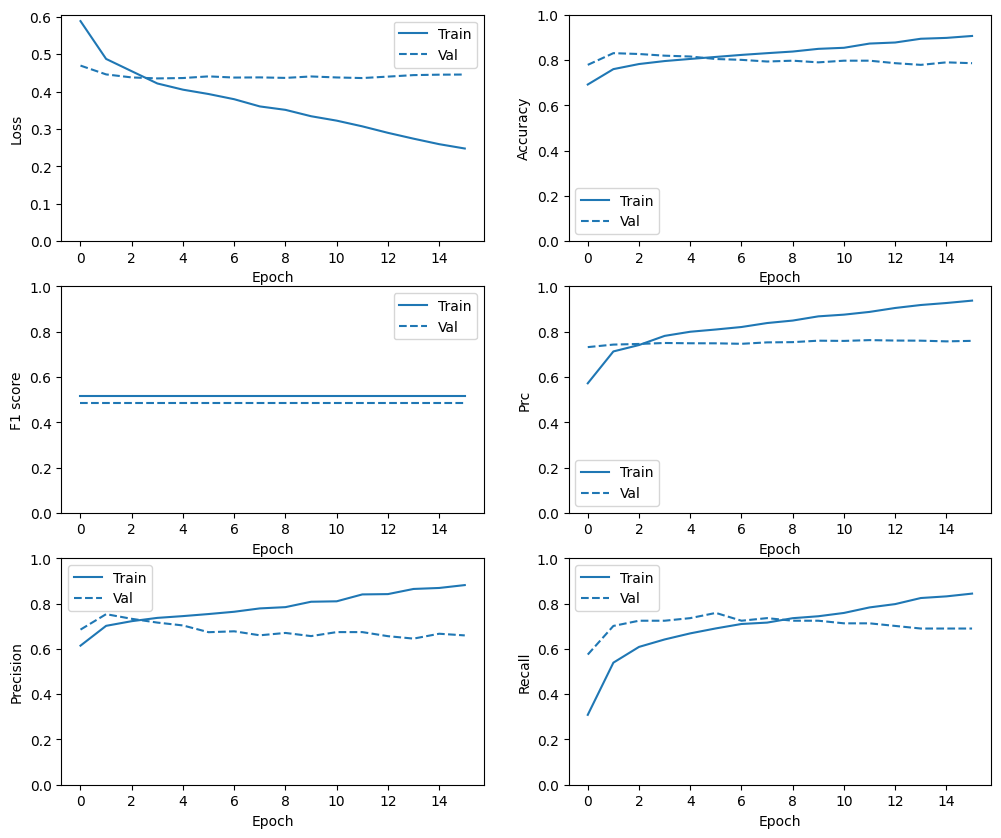

In [102]:
plot_metrics(history)

In [103]:
y_pred = vgg_16_model.predict(test_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 133s 6s/step


In [110]:
new_y_pred = np.where(y_pred > 0.3, 1, 0)
new_y_pred = new_y_pred.flatten()
new_y_pred

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,

In [111]:
y_true = []
for x, y in test_ds:
  for i in y:
    y_true.append(i.numpy().item())
y_true = np.array(y_true)
y_true

array([0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,

In [112]:
print(len(y_true), len(new_y_pred))

736 736


In [113]:
acc = accuracy_score(y_true, new_y_pred)
precision = precision_score(y_true, new_y_pred)
recall = recall_score(y_true, new_y_pred)
f1_val = f1_score(y_true, new_y_pred)


print(f"Accuracy: {acc}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_val}")

Accuracy: 0.5217391304347826
Precision: 0.3778501628664495
Recall: 0.4187725631768953
F1 Score: 0.3972602739726027
